In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
%pwd

'/home/binardo/git/ML_pro/Module 1 IA Méthodo/1.5-methodologie-de-l-IA/06_Projets finaux/ML__Pro_Real_estate_Price_Prediction'

In [3]:
df = pd.read_csv('data/kaggle_train_set.csv')

df

,OverallQual,GrLivArea,TotalBsmtSF,1stFlrSF,YearBuilt,YearRemodAdd,GarageCars,GarageArea,FullBath,TotRmsAbvGrd,KitchenQual,Fireplaces,LotArea,Neighborhood,ExterQual,SalePrice
0,7,1710,856,856,2003,2003,2,548,2,8,Gd,0,8450,CollgCr,Gd,208500
1,6,1262,1262,1262,1976,1976,2,460,2,6,TA,1,9600,Veenker,TA,181500
2,7,1786,920,920,2001,2002,2,608,2,6,Gd,1,11250,CollgCr,Gd,223500
3,8,1694,1686,1694,2004,2005,2,636,2,7,Gd,1,10084,Somerst,Gd,307000
4,7,1774,952,1022,1931,1950,2,468,2,8,TA,2,6120,OldTown,TA,129900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,5,1072,547,1072,2005,2005,2,525,1,5,TA,0,3675,Edwards,TA,145000
1176,7,1221,1221,1221,2004,2005,2,400,2,6,Gd,0,7500,Somerst,Gd,185000
1177,6,1647,953,953,1999,2000,2,460,2,7,TA,1,7917,Gilbert,TA,175000
1178,7,2340,1152,1188,1941,2006,1,252,2,9,Gd,2,9042,Crawfor,Ex,266500


In [4]:
df.describe()

,OverallQual,GrLivArea,TotalBsmtSF,1stFlrSF,YearBuilt,YearRemodAdd,GarageCars,GarageArea,FullBath,TotRmsAbvGrd,Fireplaces,LotArea,SalePrice
count,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000,1180.000000
mean,6.095763,1508.277966,1058.874576,1163.179661,1970.688983,1984.511017,1.752542,468.944915,1.552542,6.486441,0.609322,10448.989831,179822.169492
std,1.383956,534.634371,448.648614,395.100829,30.002104,20.775770,0.750314,211.898970,0.549302,1.630078,0.650502,10266.492616,79703.346024
min,1.000000,334.000000,0.000000,334.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1300.000000,34900.000000
25%,5.000000,1118.000000,793.000000,879.750000,1953.000000,1966.000000,1.000000,312.000000,1.000000,5.000000,0.000000,7500.000000,128800.000000
50%,6.000000,1441.500000,993.500000,1088.000000,1972.000000,1993.000000,2.000000,474.000000,2.000000,6.000000,1.000000,9458.500000,161250.000000
75%,7.000000,1779.000000,1309.500000,1392.000000,2000.000000,2004.000000,2.000000,576.000000,2.000000,7.000000,1.000000,11532.750000,212000.000000
max,10.000000,5642.000000,6110.000000,4692.000000,2010.000000,2010.000000,4.000000,1418.000000,3.000000,14.000000,3.000000,215245.000000,755000.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1180 entries, 0 to 1179
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   OverallQual   1180 non-null   int64
 1   GrLivArea     1180 non-null   int64
 2   TotalBsmtSF   1180 non-null   int64
 3   1stFlrSF      1180 non-null   int64
 4   YearBuilt     1180 non-null   int64
 5   YearRemodAdd  1180 non-null   int64
 6   GarageCars    1180 non-null   int64
 7   GarageArea    1180 non-null   int64
 8   FullBath      1180 non-null   int64
 9   TotRmsAbvGrd  1180 non-null   int64
 10  KitchenQual   1180 non-null   str  
 11  Fireplaces    1180 non-null   int64
 12  LotArea       1180 non-null   int64
 13  Neighborhood  1180 non-null   str  
 14  ExterQual     1180 non-null   str  
 15  SalePrice     1180 non-null   int64
dtypes: int64(13), str(3)
memory usage: 147.6 KB


- Almost entirely numeric columns. But mostly Discrete Columns

- Discrete columns : ["OverallQual", "Fireplaces",  "Neighborhood", "ExterQual", "KitchenQual", "Full Bath", "GarageCars", "TotRmsAbvGrd"]

- Continuous columns : ["GrLivArea", "GarageArea", "LotArea, , "YearBuilt",	"YearRemodAdd"", "TotalBsmtSF", "1stFlrSF", "Price"]

- Only 3 categorical columns to encode: "Neighborhood", "ExterQual", "KitchenQual". The encoding type needs to be determined: OneHot or Ordinal.

- Clean dataset; no null values ​​in any column, so no need to handle NaNs.

In [6]:
continuous_col = ["GrLivArea", "GarageArea", "LotArea", "YearBuilt", "YearRemodAdd", "TotalBsmtSF", "1stFlrSF", "SalePrice"]
discrete_col   = ["OverallQual", "Fireplaces",  "Neighborhood", "ExterQual", "KitchenQual", "FullBath", "GarageCars", "TotRmsAbvGrd"]

In [ ]:
def univariate_discrete_analysis(df, discrete_col):
    """
    Perform univariate analysis on discrete (categorical) columns.

    For each column, displays:
    - Value counts (frequency of each category)
    - A count plot sorted by frequency (most common first)

    Parameters
    ----------
    df : pd.DataFrame
        The dataset to analyse.
    discrete_col : list of str
        Names of the categorical columns to analyse.

    Example
    -------
    univariate_discrete_analysis(df=df, discrete_col=discrete_col)
    """
    for col in discrete_col:
        print(f'### analysing column : {col} ###')

        # Count occurrences of each category, sorted descending
        count = df[col].value_counts()
        display(count)

        plt.figure(figsize=(8, 4))

        # order=count.index ensures bars are sorted by frequency (most common first)
        sns.countplot(data=df, x=col, order=count.index)

        plt.title(f'Distribution of {col}')
        plt.xticks(rotation=45)  # Rotate labels to avoid overlap on long category names
        plt.tight_layout()
        plt.show()


def univariate_continuous_analysis(df, continuous_col):
    """
    Perform univariate analysis on continuous (numerical) columns.

    For each column, displays:
    - Descriptive statistics (count, mean, std, min, quartiles, max)
    - Variance (spread of the distribution, sensitive to outliers)
    - Histogram with KDE overlay (shape of the distribution)
    - Boxplot (spread, median, and outlier detection)

    Parameters
    ----------
    df : pd.DataFrame
        The dataset to analyse.
    continuous_col : list of str
        Names of the numerical columns to analyse.

    Example
    -------
    univariate_continuous_analysis(df=df, continuous_col=continuous_col)
    """
    for col in continuous_col:
        print(f'### analysing column : {col} ###')

        # describe() gives count, mean, std, min, 25/50/75th percentiles, max
        stats    = df[col].describe()
        variance = df[col].var()

        display(stats)
        # Variance complements std: high value signals wide spread or outliers
        print(f'Variance: {variance:.2f}')

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Left plot: histogram with KDE to visualise the distribution shape
        # kde=True overlays a smoothed density curve on the histogram
        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f'Histogram of {col}')

        # Right plot: boxplot to spot the median, IQR, and potential outliers
        sns.boxplot(x=df[col], ax=axes[1])
        axes[1].set_title(f'Boxplot of {col}')

        plt.tight_layout()
        plt.show()

### analysing column : OverallQual ###


OverallQual
5     328
6     307
7     255
8     126
4      90
9      37
10     17
3      16
2       3
1       1
Name: count, dtype: int64

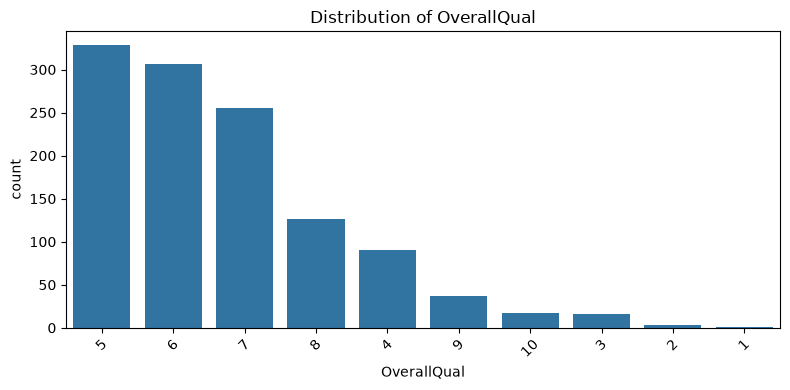

### analysing column : Fireplaces ###


Fireplaces
0    566
1    513
2     97
3      4
Name: count, dtype: int64

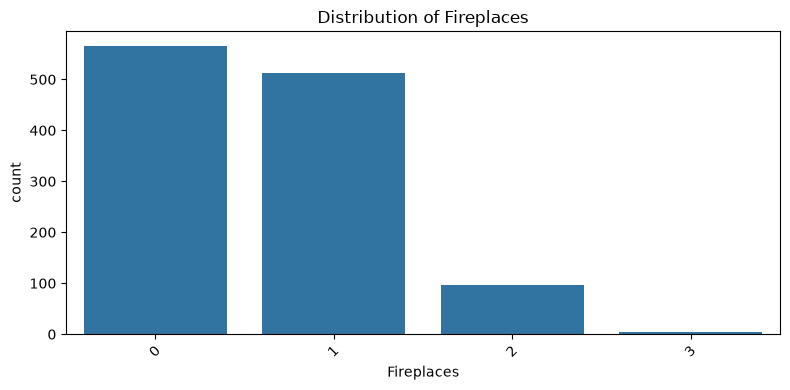

### analysing column : Neighborhood ###


Neighborhood
NAmes      198
CollgCr    120
OldTown     91
Edwards     76
Somerst     67
Sawyer      62
NridgHt     61
Gilbert     59
NWAmes      57
SawyerW     51
BrkSide     50
Crawfor     43
Mitchel     36
NoRidge     33
Timber      29
IDOTRR      24
ClearCr     23
SWISU       21
StoneBr     18
Blmngtn     16
BrDale      15
MeadowV     13
Veenker     10
NPkVill      5
Blueste      2
Name: count, dtype: int64

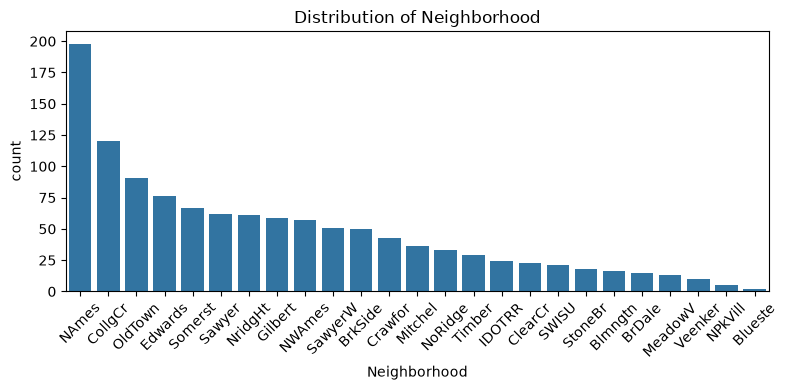

### analysing column : ExterQual ###


ExterQual
TA    742
Gd    383
Ex     44
Fa     11
Name: count, dtype: int64

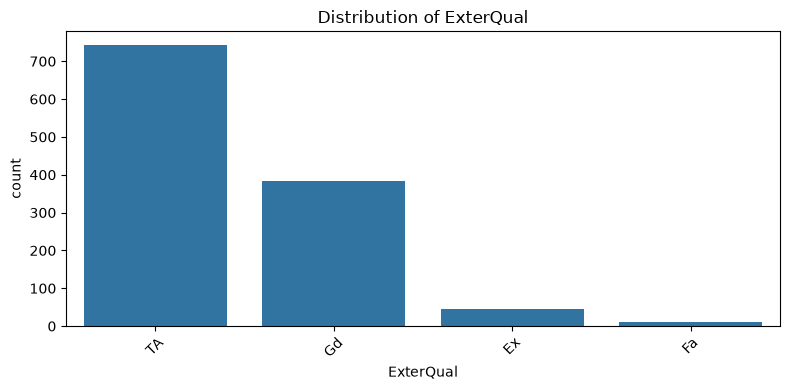

### analysing column : KitchenQual ###


KitchenQual
TA    600
Gd    462
Ex     84
Fa     34
Name: count, dtype: int64

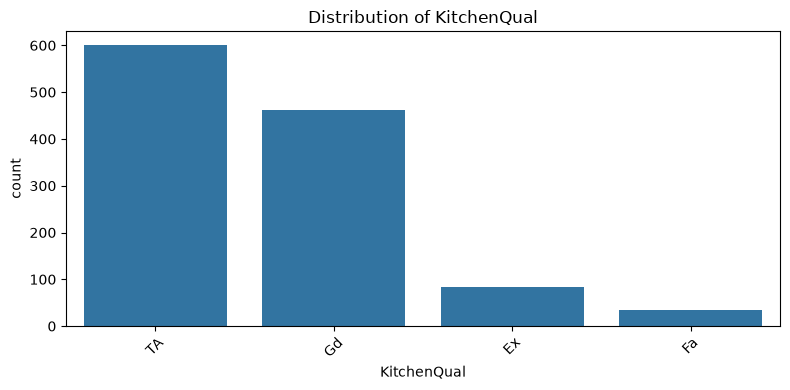

### analysing column : FullBath ###


FullBath
2    609
1    539
3     25
0      7
Name: count, dtype: int64

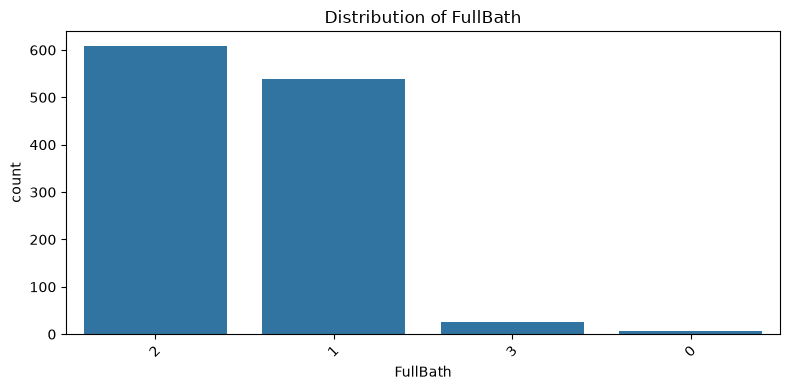

### analysing column : GarageCars ###


GarageCars
2    654
1    312
3    144
0     66
4      4
Name: count, dtype: int64

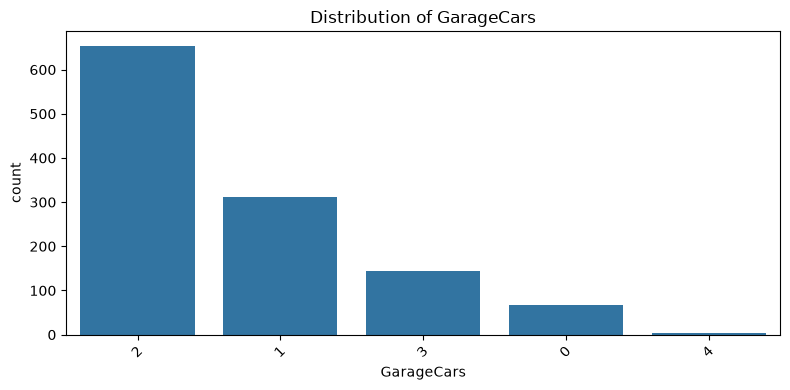

### analysing column : TotRmsAbvGrd ###


TotRmsAbvGrd
6     337
7     259
5     223
8     145
4      83
9      59
10     34
11     14
3      13
12     11
2       1
14      1
Name: count, dtype: int64

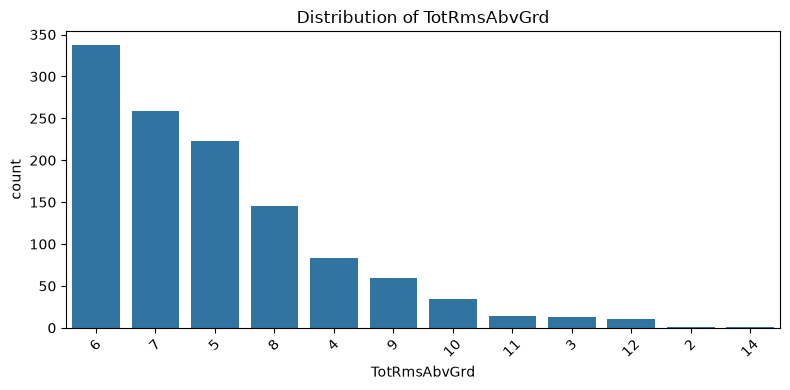

In [8]:
univariate_discrete_analysis(df=df, discrete_col=discrete_col)

### analysing column : GrLivArea ###


count    1180.000000
mean     1508.277966
std       534.634371
min       334.000000
25%      1118.000000
50%      1441.500000
75%      1779.000000
max      5642.000000
Name: GrLivArea, dtype: float64

Variance: 285833.91


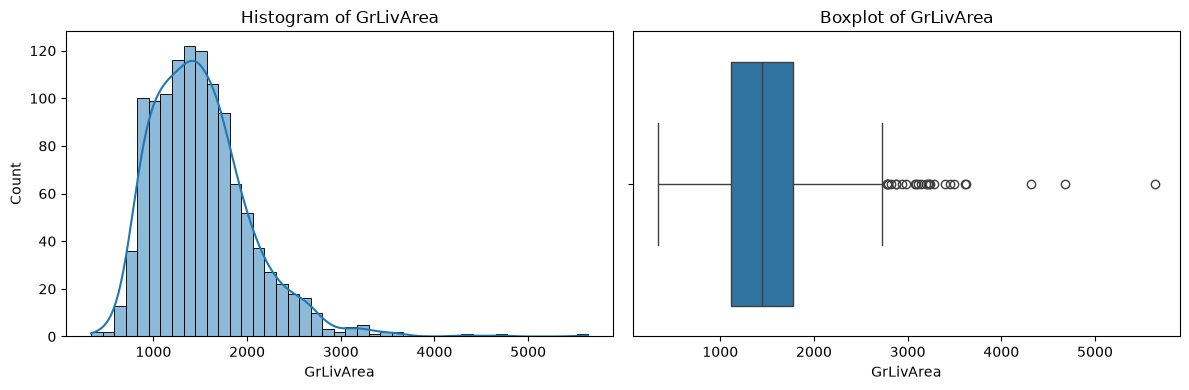

### analysing column : GarageArea ###


count    1180.000000
mean      468.944915
std       211.898970
min         0.000000
25%       312.000000
50%       474.000000
75%       576.000000
max      1418.000000
Name: GarageArea, dtype: float64

Variance: 44901.17


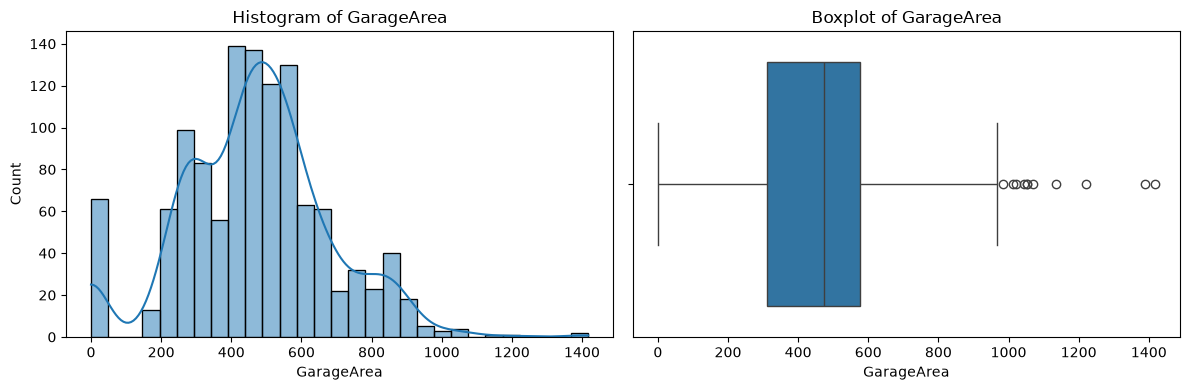

### analysing column : LotArea ###


count      1180.000000
mean      10448.989831
std       10266.492616
min        1300.000000
25%        7500.000000
50%        9458.500000
75%       11532.750000
max      215245.000000
Name: LotArea, dtype: float64

Variance: 105400870.63


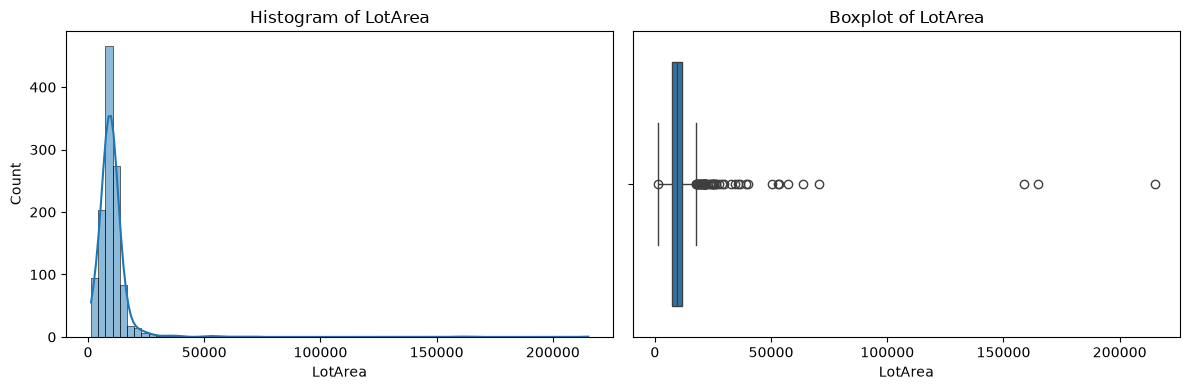

### analysing column : YearBuilt ###


count    1180.000000
mean     1970.688983
std        30.002104
min      1872.000000
25%      1953.000000
50%      1972.000000
75%      2000.000000
max      2010.000000
Name: YearBuilt, dtype: float64

Variance: 900.13


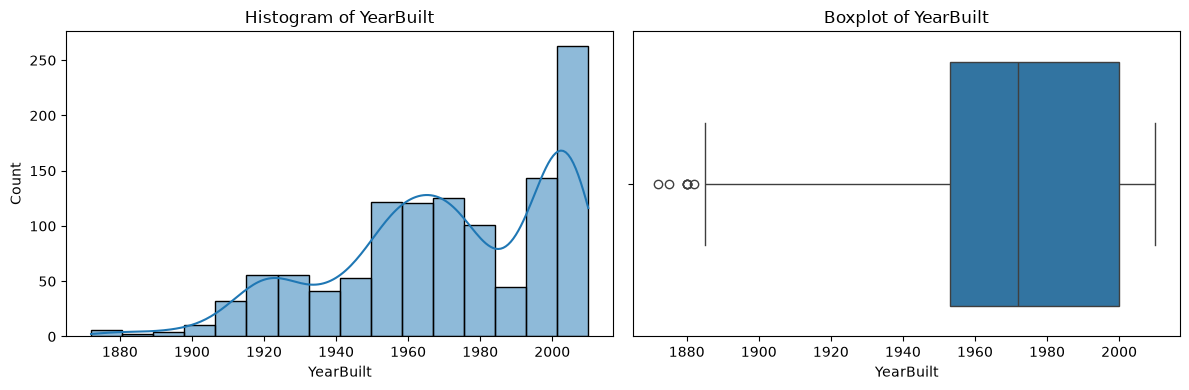

### analysing column : YearRemodAdd ###


count    1180.000000
mean     1984.511017
std        20.775770
min      1950.000000
25%      1966.000000
50%      1993.000000
75%      2004.000000
max      2010.000000
Name: YearRemodAdd, dtype: float64

Variance: 431.63


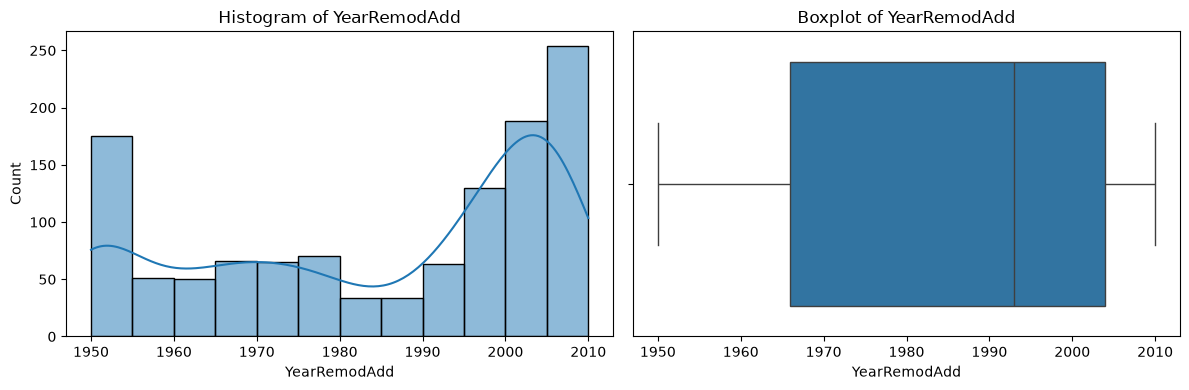

### analysing column : TotalBsmtSF ###


count    1180.000000
mean     1058.874576
std       448.648614
min         0.000000
25%       793.000000
50%       993.500000
75%      1309.500000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

Variance: 201285.58


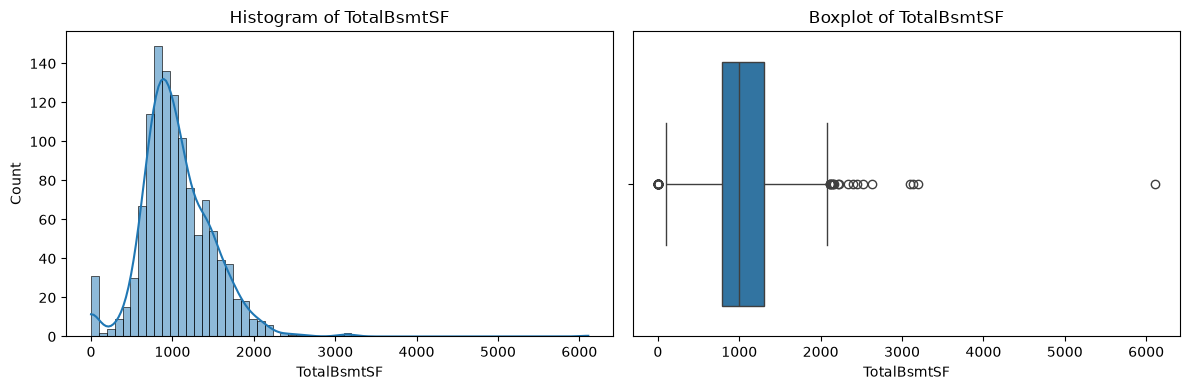

### analysing column : 1stFlrSF ###


count    1180.000000
mean     1163.179661
std       395.100829
min       334.000000
25%       879.750000
50%      1088.000000
75%      1392.000000
max      4692.000000
Name: 1stFlrSF, dtype: float64

Variance: 156104.66


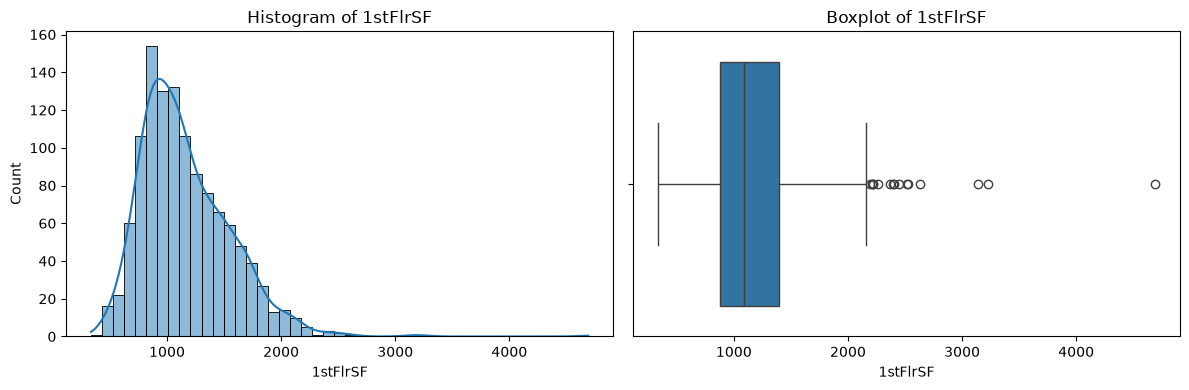

### analysing column : SalePrice ###


count      1180.000000
mean     179822.169492
std       79703.346024
min       34900.000000
25%      128800.000000
50%      161250.000000
75%      212000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Variance: 6352623367.47


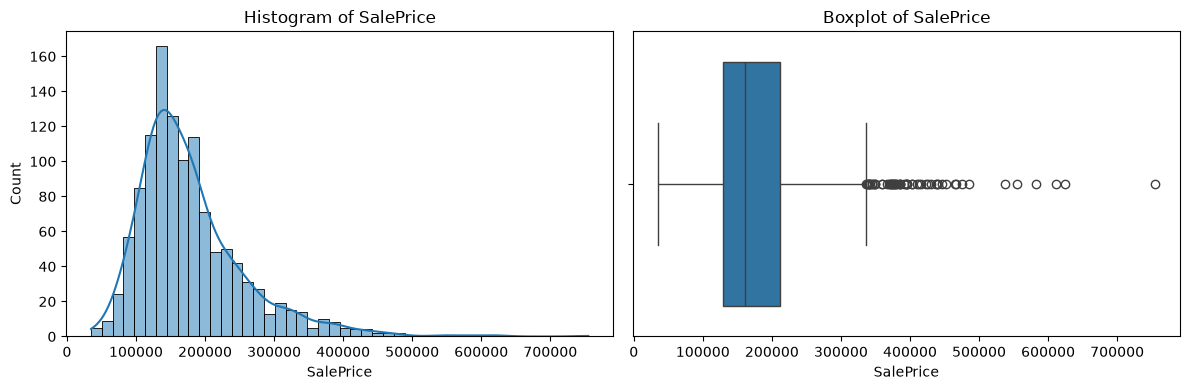

In [9]:
univariate_continuous_analysis(df=df, continuous_col=continuous_col)

In [10]:
df['KitchenQual'].value_counts()

KitchenQual
TA    600
Gd    462
Ex     84
Fa     34
Name: count, dtype: int64

In [11]:
df['ExterQual'].value_counts()

ExterQual
TA    742
Gd    383
Ex     44
Fa     11
Name: count, dtype: int64

"ExterQual" & "KitchenQual" have a clear Hierarchical order.

TA : TA = Typical/Average.

Fa : Fair

Gd : Good

Ex : Excellent

So ordinal order : Po < Fa < TA < Gd < Ex. 

In [12]:
df['Neighborhood'].value_counts()

Neighborhood
NAmes      198
CollgCr    120
OldTown     91
Edwards     76
Somerst     67
Sawyer      62
NridgHt     61
Gilbert     59
NWAmes      57
SawyerW     51
BrkSide     50
Crawfor     43
Mitchel     36
NoRidge     33
Timber      29
IDOTRR      24
ClearCr     23
SWISU       21
StoneBr     18
Blmngtn     16
BrDale      15
MeadowV     13
Veenker     10
NPkVill      5
Blueste      2
Name: count, dtype: int64

In [13]:
df['Neighborhood'].unique()

<StringArray>
['CollgCr', 'Veenker', 'Somerst', 'OldTown', 'BrkSide', 'NridgHt',  'Sawyer',
   'NAmes', 'SawyerW',  'IDOTRR', 'Edwards',  'Timber', 'Mitchel', 'Gilbert',
 'StoneBr', 'ClearCr', 'Crawfor',  'NWAmes', 'NPkVill', 'Blmngtn',  'BrDale',
 'NoRidge',   'SWISU', 'MeadowV', 'Blueste']
Length: 25, dtype: str

The neighborhoods surely have different qualities, and a resident familiar with the city would clearly understand the hierarchy between them. 

However, in the absence of information about these neighborhoods (presumably a fictional city?), we can't create an ordinal hierarchy without it. 
OneHot encoding seems like the best solution. 
But since there are 25 different neighborhoods, this would add 25 new columns (or 24 if we drop one). Does this add too many new columns ?

With approximately 1460 rows (standard Kaggle dataset), 25 additional columns are perfectly acceptable—the rule of thumb is to have at least 5-10 times more rows than columns, and wea re well above that.

The "multicorrelation" is actually the dummy variable trap: if we keep 25 columns instead of 24, one column is perfectly predictable by the others. Sklearn has a `drop='first'` parameter in OneHotEncoder to prevent this.

This problem only applies to linear models (LinearRegression). For Random Forest or XGBoost, the 25 columns pose no problem.

### 1 Preprocessing

In [14]:
#define target
y = df['SalePrice']

X = df.drop('SalePrice', axis=1)

##### EDA

<Axes: >

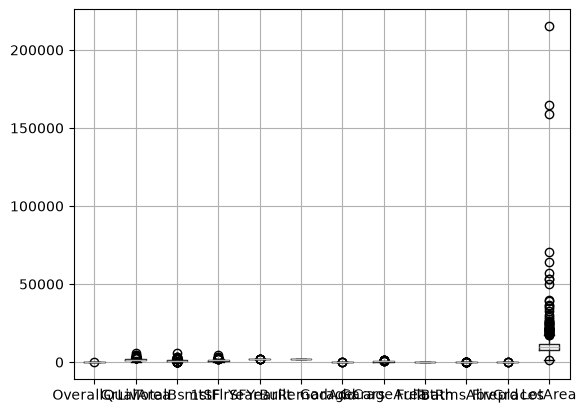

In [15]:
X.boxplot()

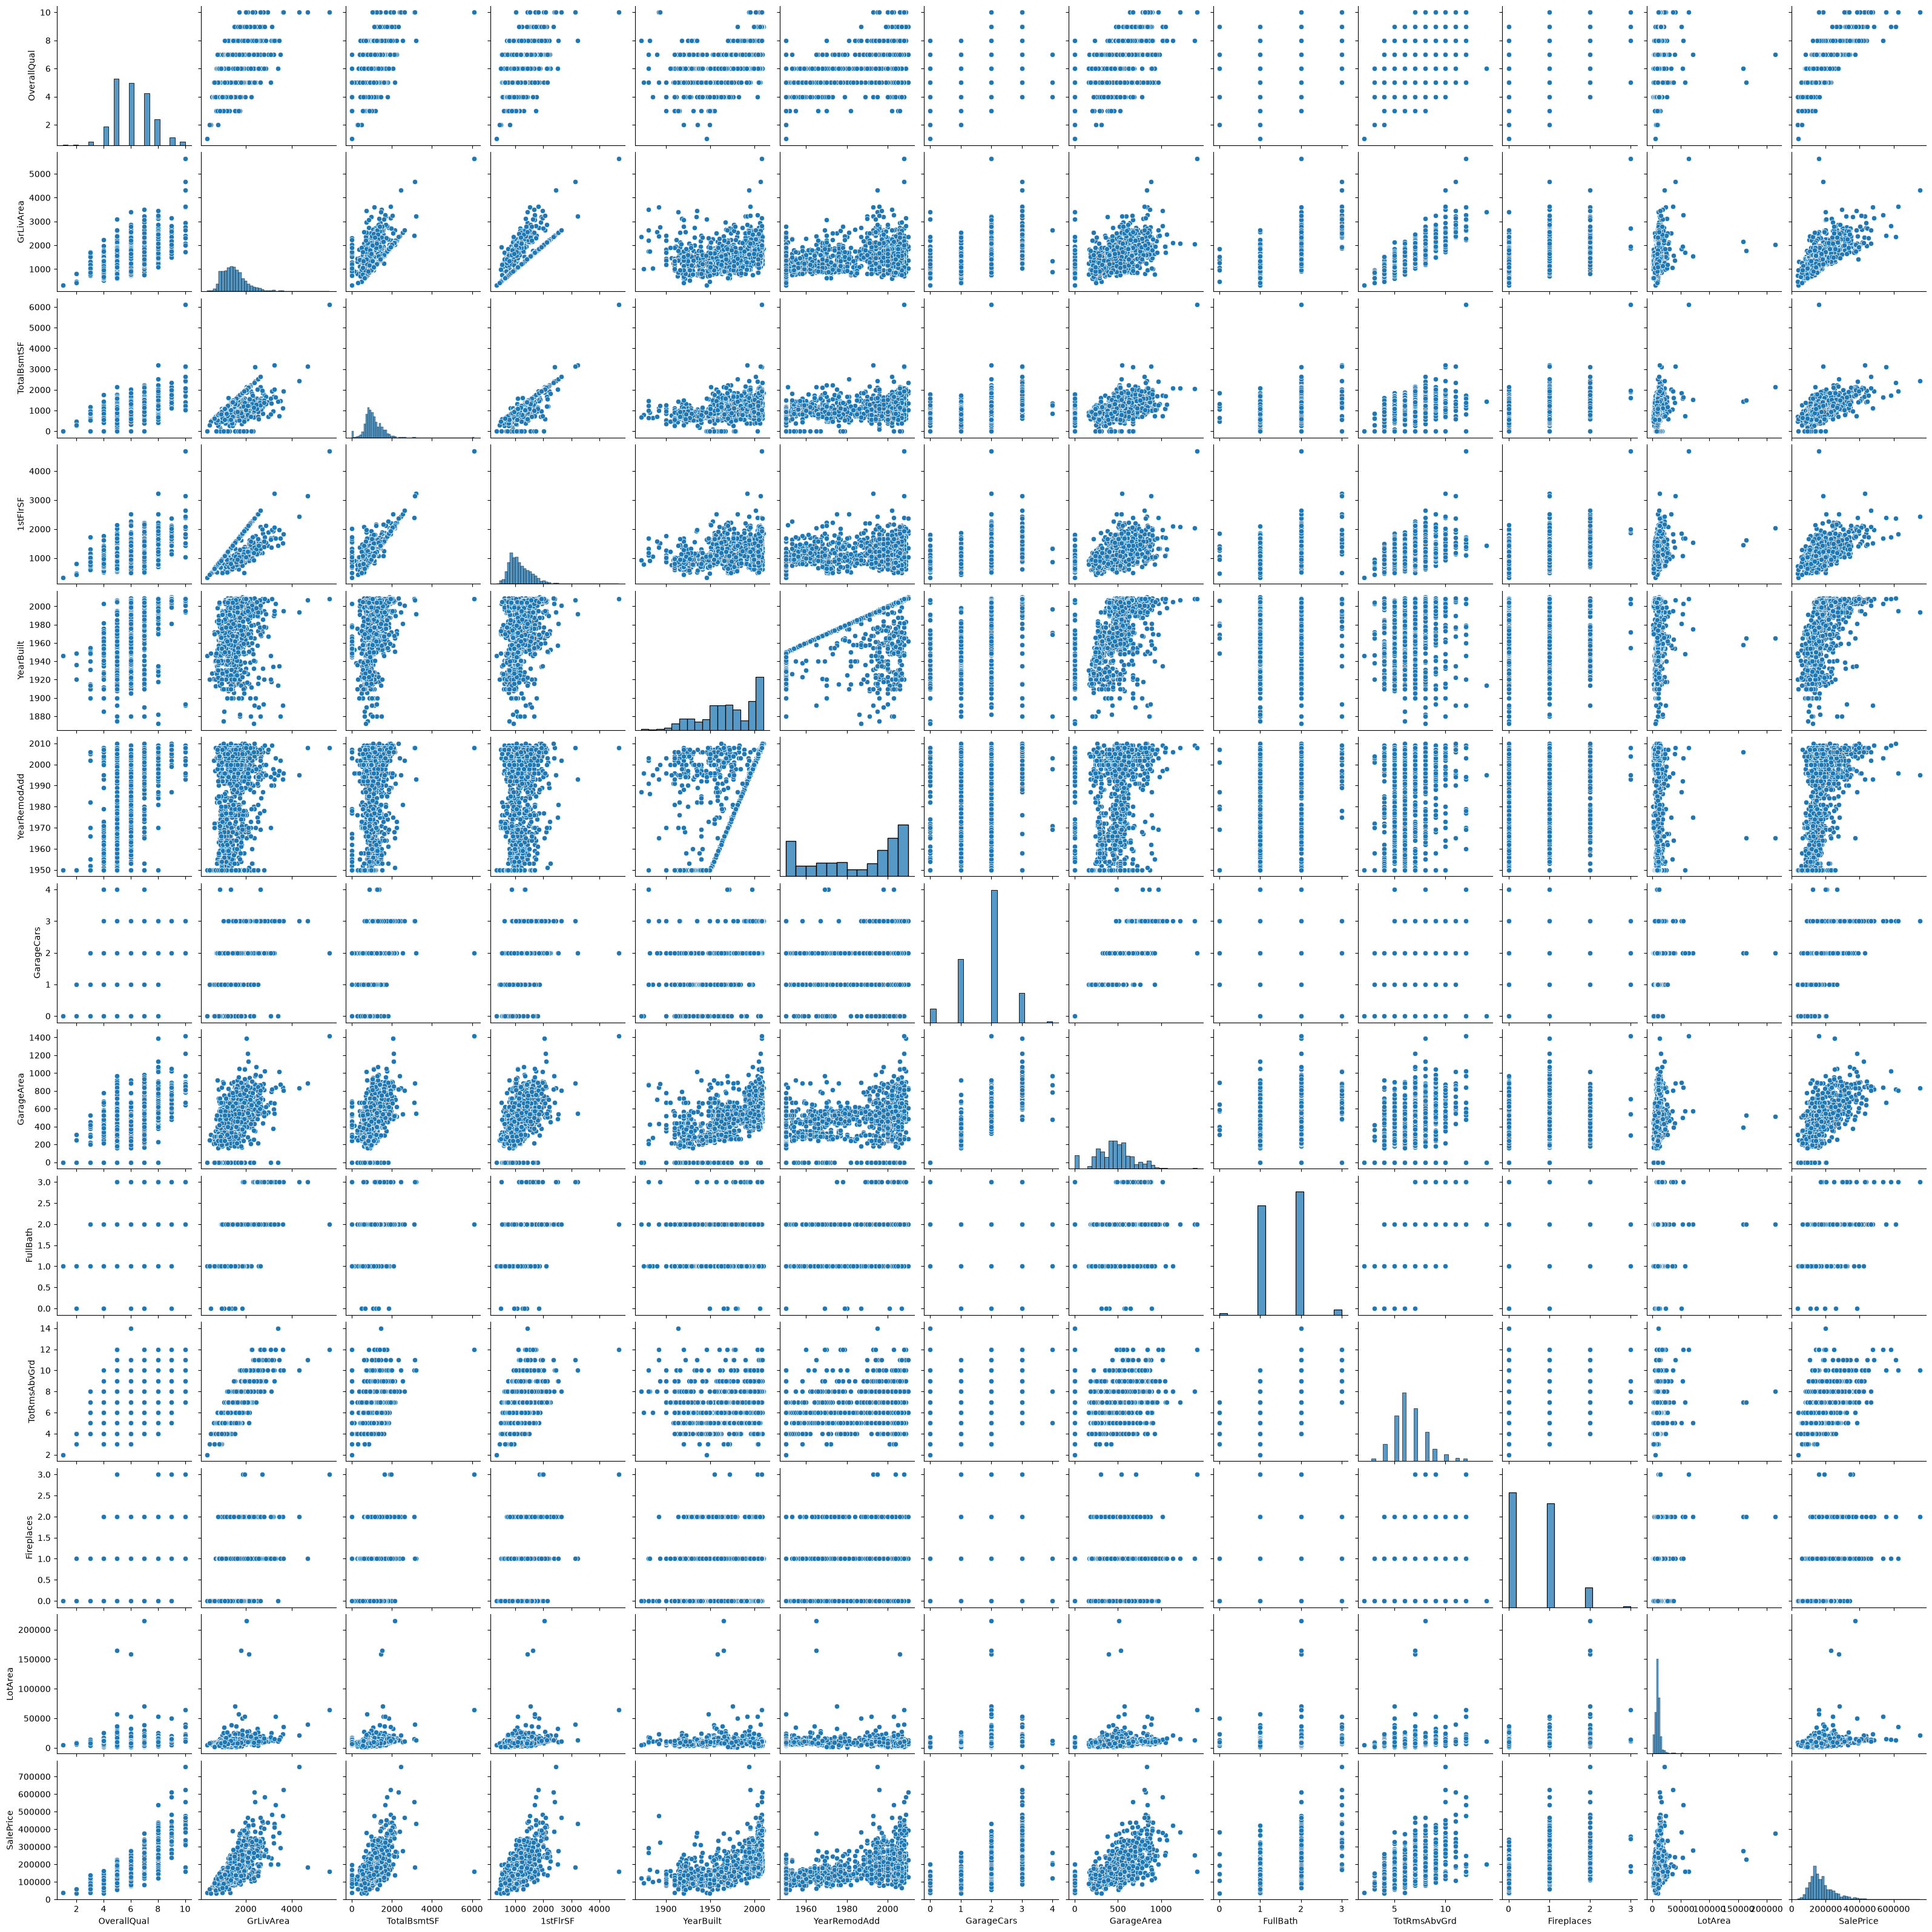

In [16]:
sns.pairplot(df)

##### Encoding

In [17]:
#ordinal encoder for ExterQual & KitchenQual
ordinal_order = ['Po' , 'Fa', 'TA', 'Gd', 'Ex']

ordinal = OrdinalEncoder(categories=[ordinal_order, ordinal_order])

#OneHot for Neighborhood
one_hot = OneHotEncoder(drop='first', sparse_output=False)

ordinal_column_transfo = ColumnTransformer(transformers=[                                           
                                            ['ordinal_preprocess', ordinal, ['KitchenQual', 'ExterQual']],
                                            ['one_hot_preprocess', one_hot, ['Neighborhood']]
                                            ],
                                            remainder='passthrough'
                                        )

In [18]:
X_transformed_raw = ordinal_column_transfo.fit_transform(X)

X_transformed = pd.DataFrame(X_transformed_raw, columns=ordinal_column_transfo.get_feature_names_out())

X_transformed.columns

Index(['ordinal_preprocess__KitchenQual', 'ordinal_preprocess__ExterQual',
       'one_hot_preprocess__Neighborhood_Blueste',
       'one_hot_preprocess__Neighborhood_BrDale',
       'one_hot_preprocess__Neighborhood_BrkSide',
       'one_hot_preprocess__Neighborhood_ClearCr',
       'one_hot_preprocess__Neighborhood_CollgCr',
       'one_hot_preprocess__Neighborhood_Crawfor',
       'one_hot_preprocess__Neighborhood_Edwards',
       'one_hot_preprocess__Neighborhood_Gilbert',
       'one_hot_preprocess__Neighborhood_IDOTRR',
       'one_hot_preprocess__Neighborhood_MeadowV',
       'one_hot_preprocess__Neighborhood_Mitchel',
       'one_hot_preprocess__Neighborhood_NAmes',
       'one_hot_preprocess__Neighborhood_NPkVill',
       'one_hot_preprocess__Neighborhood_NWAmes',
       'one_hot_preprocess__Neighborhood_NoRidge',
       'one_hot_preprocess__Neighborhood_NridgHt',
       'one_hot_preprocess__Neighborhood_OldTown',
       'one_hot_preprocess__Neighborhood_SWISU',
       'one_ho

In [19]:
#renaming columns to drop encoding prefixes
X_transformed.columns = X_transformed.columns.str.split('__').str[-1]

X_transformed.columns

Index(['KitchenQual', 'ExterQual', 'Neighborhood_Blueste',
       'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr',
       'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards',
       'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV',
       'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer',
       'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr',
       'Neighborhood_Timber', 'Neighborhood_Veenker', 'OverallQual',
       'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'YearBuilt', 'YearRemodAdd',
       'GarageCars', 'GarageArea', 'FullBath', 'TotRmsAbvGrd', 'Fireplaces',
       'LotArea'],
      dtype='str')

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, 
                                                    test_size=0.2, 
                                                    random_state=42)